CNN test accuracy: 1.0
CNN test macro-F1: 1.0


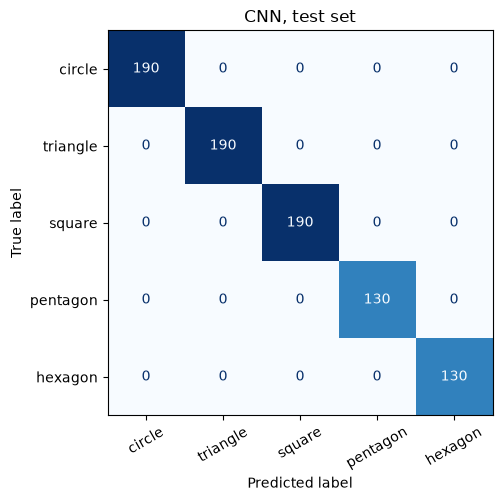

        held_out  accuracy  f1_present
0      generated    0.9864      0.9864
1      kaggle_2d    0.9955      0.9955
2  kaggle_simple    0.9867      0.9916


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(0)
np.random.seed(0)
CLASSES = ["circle", "triangle", "square", "pentagon", "hexagon"]

d = np.load("data/processed/silhouettes_64.npz")
X, y = d["X"], d["y"]
meta = pd.read_csv("data/processed/dataset.csv")
Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1) / 255.0
yt = torch.tensor(y, dtype=torch.long)


def make_model():
    return nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(), nn.Dropout(0.3),
        nn.Linear(64 * 8 * 8, 64), nn.ReLU(), nn.Linear(64, 5))


def train_eval(tr_idx, te_idx, epochs=12, bs=64):
    model = make_model()
    opt = torch.optim.Adam(model.parameters(), 1e-3)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        perm = tr_idx[torch.randperm(len(tr_idx))]
        for i in range(0, len(perm), bs):
            b = perm[i:i + bs]
            xb, yb = Xt[b], yt[b]
            xb = torch.rot90(xb, int(np.random.randint(4)), (2, 3))   # shape-preserving augmentation
            if np.random.rand() < 0.5:
                xb = torch.flip(xb, (3,))
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xt[te_idx]).argmax(1).numpy()
    return model, pred


# --- standard train/test split ---
is_train = (meta.split == "train").to_numpy()
tr = torch.tensor(np.where(is_train)[0])
te = torch.tensor(np.where(~is_train)[0])
model, pred = train_eval(tr, te)
true = y[te.numpy()]

print("CNN test accuracy:", round(accuracy_score(true, pred), 4))
print("CNN test macro-F1:", round(f1_score(true, pred, average="macro"), 4))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(true, pred), display_labels=CLASSES).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("CNN, test set")
plt.xticks(rotation=30)
fig.savefig("outputs/cnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# --- leave-one-source-out ---
rows = []
for src in meta.source.unique():
    tr_i = torch.tensor(np.where(is_train & (meta.source != src).to_numpy())[0])
    te_i = torch.tensor(np.where((meta.source == src).to_numpy())[0])
    _, p = train_eval(tr_i, te_i)
    t = y[te_i.numpy()]
    rows.append({"held_out": src, "accuracy": accuracy_score(t, p),
                 "f1_present": f1_score(t, p, labels=np.unique(t), average="macro")})
loso = pd.DataFrame(rows)
print(loso.round(4))
loso.to_csv("outputs/cnn_leave_one_source_out.csv", index=False)